# 构建智能体
 
> 注意：可选择性地，在深入这个notebook之前，请先查看[这些幻灯片](https://docs.google.com/presentation/d/13c0L1CQWAL7fuCXakOqjkvoodfynPJI4Hw_4H76okVU/edit?usp=sharing)和[langgraph_101.ipynb](langgraph_101.ipynb)获取背景信息！

我们将从头开始构建一个电子邮件助手，从这里开始：1) 智能体架构（使用[LangGraph](https://langchain-ai.github.io/langgraph/)），然后是 2) 测试（使用[LangSmith](https://docs.smith.langchain.com/)），3) 人工干预，以及 4) 记忆。这个图表展示了这些组件如何配合工作：

![overview-img](img/overview.png)

#### 加载环境变量

In [1]:
from dotenv import load_dotenv
load_dotenv("../.env")

True

## 工具定义

让我们首先使用 `@tool` 装饰器定义一些电子邮件助手将使用的简单工具：

In [2]:
from typing import Literal
from datetime import datetime
from pydantic import BaseModel
from langchain_core.tools import tool

@tool
def write_email(to: str, subject: str, content: str) -> str:
    """撰写并发送电子邮件。"""
    # 占位符响应 - 在真实应用中会发送电子邮件
    return f"电子邮件已发送至 {to}，主题为 '{subject}'，内容为：{content}"

@tool
def schedule_meeting(
    attendees: list[str], subject: str, duration_minutes: int, preferred_day: datetime, start_time: int
) -> str:
    """安排日历会议。"""
    # 占位符响应 - 在真实应用中会检查日历并安排会议
    date_str = preferred_day.strftime("%A, %B %d, %Y")
    return f"会议 '{subject}' 已安排在 {date_str} {start_time} 点，持续 {duration_minutes} 分钟，有 {len(attendees)} 位参与者"

@tool
def check_calendar_availability(day: str) -> str:
    """检查指定日期的日历可用性。"""
    # 占位符响应 - 在真实应用中会检查实际日历
    return f"{day} 的可用时间：上午9:00，下午2:00，下午4:00"

@tool
class Done(BaseModel):
      """电子邮件已发送。"""
      done: bool

## 构建我们的电子邮件助手

我们将结合[路由器和智能体](https://langchain-ai.github.io/langgraph/tutorials/workflows/)来构建我们的电子邮件助手。

![agent_workflow_img](img/email_workflow.png)

### 路由器

路由步骤处理分类决策。

分类路由器只专注于分类决策，而智能体只专注于响应。

#### 状态

在构建智能体时，重要的是考虑您想要随时间跟踪的信息。我们将使用 LangGraph 的预构建[`MessagesState` 对象](https://langchain-ai.github.io/langgraph/concepts/low_level/#messagesstate)，它只是一个带有 `messages` 键的字典，该键会追加节点返回的消息[作为其更新逻辑](https://langchain-ai.github.io/langgraph/concepts/low_level/#reducers)。但是，LangGraph 为您提供了跟踪其他信息的灵活性。我们将定义一个自定义的 `State` 对象，它扩展 `MessagesState` 并添加一个 `classification_decision` 键：

In [3]:
from langgraph.graph import MessagesState

class State(MessagesState):
    # 我们可以为电子邮件输入在状态中添加特定的键
    email_input: dict
    classification_decision: Literal["ignore", "respond", "notify"]

#### 分类节点

我们定义一个带有分类路由逻辑的 Python 函数。

为此，我们使用[结构化输出](https://python.langchain.com/docs/concepts/structured_outputs/)与 Pydantic 模型，这对于定义结构化输出模式特别有用，因为它提供了类型提示和验证。Pydantic 模型中的描述很重要，因为它们作为 JSON 模式的一部分传递给 LLM，以指导输出强制转换。

In [4]:
%load_ext autoreload
%autoreload 2
import sys
import os
sys.path.append('../src')
    
from pydantic import BaseModel, Field
from email_assistant.utils import parse_email, format_email_markdown
from email_assistant.prompts import triage_system_prompt, triage_user_prompt, default_triage_instructions, default_background
from langchain.chat_models import init_chat_model
from langgraph.graph import END
from langgraph.types import Command

In [5]:
from rich.markdown import Markdown
Markdown(triage_system_prompt)

< Role > Your role is to triage incoming emails based upon instructs and background information below. </ Role >   

< Background > {background}. </ Background >                                                                       

< Instructions > Categorize each email into one of three categories:                                               

 1 IGNORE - Emails that are not worth responding to or tracking                                                    
 2 NOTIFY - Important information that worth notification but doesn't require a response                           
 3 RESPOND - Emails that need a direct response Classify the below email into one of these categories. </          
   Instructions >                                                                                                  

< Rules > {triage_instructions} </ Rules >

In [6]:
Markdown(triage_user_prompt)

Please determine how to handle the below email thread:                                                             

From: {author} To: {to} Subject: {subject} {email_thread}

In [7]:
Markdown(default_background)

I'm Lance, a software engineer at LangChain.

In [8]:
Markdown(default_triage_instructions)

Emails that are not worth responding to:                                                                           

 • Marketing newsletters and promotional emails                                                                    
 • Spam or suspicious emails                                                                                       
 • CC'd on FYI threads with no direct questions                                                                    

There are also other things that should be known about, but don't require an email response. For these, you should 
notify (using the notify response). Examples of this include:                                                      

 • Team member out sick or on vacation                                                                             
 • Build system notifications or deployments                                                                       
 • Project status updates without action items                                                                     
 • Important company announcements                                                                                 
 • FYI emails that contain relevant information for current projects                                               
 • HR Department deadline reminders                                                                                
 • Subscription status / renewal reminders                                                                         
 • GitHub notifications                                                                                            

Emails that are worth responding to:                                                                               

 • Direct questions from team members requiring expertise                                                          
 • Meeting requests requiring confirmation                                                                         
 • Critical bug reports related to team's projects                                                                 
 • Requests from management requiring acknowledgment                                                               
 • Client inquiries about project status or features                                                               
 • Technical questions about documentation, code, or APIs (especially questions about missing endpoints or         
   features)                                                                                                       
 • Personal reminders related to family (wife / daughter)                                                          
 • Personal reminder related to self-care (doctor appointments, etc)

In [9]:
class RouterSchema(BaseModel):
    """分析未读电子邮件并根据其内容进行路由。"""

    reasoning: str = Field(
        description="分类背后的逐步推理。"
    )
    classification: Literal["ignore", "respond", "notify"] = Field(
        description="电子邮件的分类：'ignore' 表示不相关的电子邮件，"
        "'notify' 表示不需要回复的重要信息，"
        "'respond' 表示需要回复的电子邮件",
    )

# 初始化用于路由器/结构化输出的 LLM
llm = init_chat_model("openai:gpt-4.1", temperature=0.0)
llm_router = llm.with_structured_output(RouterSchema) 

def triage_router(state: State) -> Command[Literal["response_agent", "__end__"]]:
    """分析电子邮件内容以决定是否应该响应、通知或忽略。"""
    
    author, to, subject, email_thread = parse_email(state["email_input"])
    system_prompt = triage_system_prompt.format(
        background=default_background,
        triage_instructions=default_triage_instructions
    )

    user_prompt = triage_user_prompt.format(
        author=author, to=to, subject=subject, email_thread=email_thread
    )

    result = llm_router.invoke(
        [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ]
    )
    
    if result.classification == "respond":
        print("📧 分类：响应 - 这封电子邮件需要回复")
        goto = "response_agent"
        update = {
            "messages": [
                {
                    "role": "user",
                    "content": f"回复电子邮件：\n\n{format_email_markdown(subject, author, to, email_thread)}",
                }
            ],
            "classification_decision": result.classification,
        }
        
    elif result.classification == "ignore":
        print("🚫 分类：忽略 - 这封电子邮件可以安全忽略")
        goto = END
        update =  {
            "classification_decision": result.classification,
        }
        
    elif result.classification == "notify":
        print("🔔 分类：通知 - 这封电子邮件包含重要信息")
        # 现在，我们转到 END。但稍后我们会添加更多内容！
        goto = END
        update = {
            "classification_decision": result.classification,
        }
        
    else:
        raise ValueError(f"无效的分类：{result.classification}")
    return Command(goto=goto, update=update)

我们在 LangGraph 中使用[Command](https://langchain-ai.github.io/langgraph/how-tos/command/)对象来既更新状态又选择要访问的下一个节点。这是边的有用替代方案。

### 智能体

现在，让我们构建智能体。

#### LLM 节点

在这里，我们定义 LLM 决策节点。这个节点接收当前状态，调用 LLM，并用 LLM 输出更新 `messages`。

我们通过设置 `tool_choice="required"` 来[使用 OpenAI 强制工具使用](https://python.langchain.com/docs/how_to/tool_choice/)。

In [10]:
from email_assistant.tools.default.prompt_templates import AGENT_TOOLS_PROMPT
from email_assistant.prompts import agent_system_prompt, default_response_preferences, default_cal_preferences

In [11]:
Markdown(AGENT_TOOLS_PROMPT)

 1 write_email(to, subject, content) - Send emails to specified recipients                                         
 2 schedule_meeting(attendees, subject, duration_minutes, preferred_day, start_time) - Schedule calendar meetings  
   where preferred_day is a datetime object                                                                        
 3 check_calendar_availability(day) - Check available time slots for a given day                                   
 4 Done - E-mail has been sent

In [12]:
Markdown(agent_system_prompt)

< Role > You are a top-notch executive assistant who cares about helping your executive perform as well as         
possible. </ Role >                                                                                                

< Tools > You have access to the following tools to help manage communications and schedule: {tools_prompt} </     
Tools >                                                                                                            

< Instructions > When handling emails, follow these steps:                                                         

 1 Carefully analyze the email content and purpose                                                                 
 2 IMPORTANT --- always call a tool and call one tool at a time until the task is complete:                        
 3 For responding to the email, draft a response email with the write_email tool                                   
 4 For meeting requests, use the check_calendar_availability tool to find open time slots                          
 5 To schedule a meeting, use the schedule_meeting tool with a datetime object for the preferred_day parameter     
    • Today's date is 2025-09-25 - use this for scheduling meetings accurately                                     
 6 If you scheduled a meeting, then draft a short response email using the write_email tool                        
 7 After using the write_email tool, the task is complete                                                          
 8 If you have sent the email, then use the Done tool to indicate that the task is complete </ Instructions >      

< Background > {background} </ Background >                                                                        

< Response Preferences > {response_preferences} </ Response Preferences >                                          

< Calendar Preferences > {cal_preferences} </ Calendar Preferences >

In [13]:
# 收集所有工具
tools = [write_email, schedule_meeting, check_calendar_availability, Done]
tools_by_name = {tool.name: tool for tool in tools}

# 初始化 LLM，强制工具使用
llm = init_chat_model("openai:gpt-4.1", temperature=0.0)
llm_with_tools = llm.bind_tools(tools, tool_choice="any")

def llm_call(state: State):
    """LLM 决定是否调用工具"""

    return {
        "messages": [
            # 调用 LLM
            llm_with_tools.invoke(
                # 添加系统提示
                [   
                    {"role": "system", "content": agent_system_prompt.format(
                        tools_prompt=AGENT_TOOLS_PROMPT,
                        background=default_background,
                        response_preferences=default_response_preferences,
                        cal_preferences=default_cal_preferences, 
                    )}
                ]
                # 将当前消息添加到提示中
                + state["messages"]
            )
        ]
    }

#### 工具处理节点

在 LLM 做出决策后，我们需要执行选择的工具。

`tool_handler` 节点执行工具。我们可以看到节点可以更新图状态以捕获任何重要的状态变化，例如分类决策。

In [14]:
def tool_handler(state: State):
    """执行工具调用。"""

    # 工具消息列表
    result = []
    
    # 遍历工具调用
    for tool_call in state["messages"][-1].tool_calls:
        # 获取工具
        tool = tools_by_name[tool_call["name"]]
        # 运行它
        observation = tool.invoke(tool_call["args"])
        # 创建工具消息
        result.append({"role": "tool", "content" : observation, "tool_call_id": tool_call["id"]})
    
    # 将其添加到我们的消息中
    return {"messages": result}

#### 条件路由

我们的智能体需要决定何时继续使用工具以及何时停止。这个条件路由函数指导智能体继续或终止。

In [15]:
def should_continue(state: State) -> Literal["tool_handler", "__end__"]:
    """路由到工具处理器，或如果调用了 Done 工具则结束。"""
    
    # 获取最后一条消息
    messages = state["messages"]
    last_message = messages[-1]
    
    # 检查是否是 Done 工具调用
    if last_message.tool_calls:
        for tool_call in last_message.tool_calls: 
            if tool_call["name"] == "Done":
                return END
            else:
                return "tool_handler"

#### 智能体图

最后，我们可以组装所有组件：

In [16]:
from langgraph.graph import StateGraph, START, END
from email_assistant.utils import show_graph

# 构建工作流
overall_workflow = StateGraph(State)

# 添加节点
overall_workflow.add_node("llm_call", llm_call)
overall_workflow.add_node("tool_handler", tool_handler)

# 添加边
overall_workflow.add_edge(START, "llm_call")
overall_workflow.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        "tool_handler": "tool_handler",
        END: END,
    },
)
overall_workflow.add_edge("tool_handler", "llm_call")

# 编译智能体
agent = overall_workflow.compile()

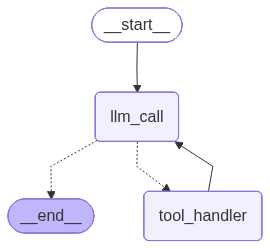

In [17]:
# 查看
show_graph(agent)

这创建了一个图：
1. 从 LLM 决策开始
2. 有条件地路由到工具执行或终止
3. 工具执行后，返回到 LLM 进行下一个决策
4. 重复直到完成或没有调用工具

### 将工作流与我们的智能体结合

我们可以结合路由器和智能体。

In [18]:
overall_workflow = (
    StateGraph(State)
    .add_node(triage_router)
    .add_node("response_agent", agent)
    .add_edge(START, "triage_router")
).compile()

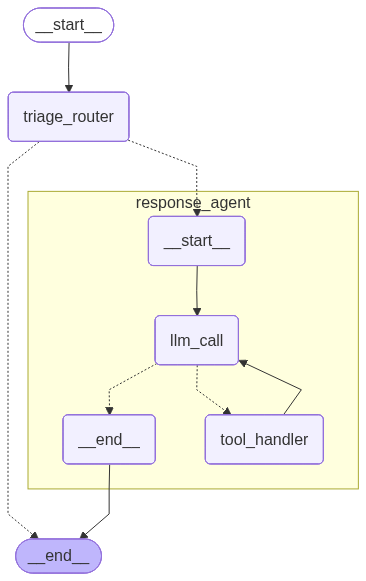

In [19]:
show_graph(overall_workflow, xray=True)

这是一个更高级的组合，其中：
1. 首先，分类路由器分析电子邮件
2. 如果需要，响应智能体处理回复的制作
3. 当分类决定不需要响应或响应智能体完成时，工作流结束

In [20]:
email_input = {
    "author": "系统管理员 <sysadmin@company.com>",
    "to": "开发团队 <dev@company.com>",
    "subject": "计划维护 - 数据库停机",
    "email_thread": "嗨团队，\n\n这是提醒您我们今晚将在东部标准时间凌晨2点到4点对生产数据库进行计划维护。在此期间，所有数据库服务将不可用。\n\n请相应地安排您的工作，并确保在此时间窗口内不安排关键部署。\n\n谢谢，\n系统管理员团队"
}

# 运行智能体
response = overall_workflow.invoke({"email_input": email_input})
for m in response["messages"]:
    m.pretty_print()

🔔 分类：通知 - 这封电子邮件包含重要信息


In [21]:
email_input = {
  "author": "爱丽丝·史密斯 <alice.smith@company.com>",
  "to": "约翰·多伊 <john.doe@company.com>",
  "subject": "关于API文档的快速问题",
  "email_thread": "嗨约翰，\n我正在查看新认证服务的API文档，注意到规范中似乎缺少一些端点。你能帮忙澄清这是故意的还是我们应该更新文档吗？\n具体来说，我正在查看：\n- /auth/refresh\n- /auth/validate\n谢谢！\n爱丽丝"
}

# 运行智能体
response = overall_workflow.invoke({"email_input": email_input})
for m in response["messages"]:
    m.pretty_print()

🔔 分类：通知 - 这封电子邮件包含重要信息


## 使用本地部署进行测试

您可以在 `src/email_assistant` 目录中找到我们智能体的文件：

* `src/email_assistant/email_assistant.py`

您可以通过运行以下命令在 LangGraph Studio 中本地测试它们：

```
! langgraph dev
```

您可以测试的示例电子邮件：

In [22]:
{
  "author": "爱丽丝·史密斯 <alice.smith@company.com>",
  "to": "约翰·多伊 <john.doe@company.com>",
  "subject": "关于API文档的快速问题",
  "email_thread": "嗨约翰，\n我正在查看新认证服务的API文档，注意到规范中似乎缺少一些端点。你能帮忙澄清这是故意的还是我们应该更新文档吗？\n具体来说，我正在查看：\n- /auth/refresh\n- /auth/validate\n谢谢！\n爱丽丝"
}

{'author': '爱丽丝·史密斯 <alice.smith@company.com>',
 'to': '约翰·多伊 <john.doe@company.com>',
 'subject': '关于API文档的快速问题',
 'email_thread': '嗨约翰，\n我正在查看新认证服务的API文档，注意到规范中似乎缺少一些端点。你能帮忙澄清这是故意的还是我们应该更新文档吗？\n具体来说，我正在查看：\n- /auth/refresh\n- /auth/validate\n谢谢！\n爱丽丝'}

![studio-img](img/studio.png)